In [2]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # 
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"}

model = pybamm.lithium_ion.SPM(options=options)

In [3]:
# %load std500cycles_tuneparameters.py
#Parameters tuned for 500 cycles standard
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3*2 
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius


parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 48000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.4,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.2*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })





#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.001,
                        
                        })


In [156]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [4]:
from itertools import product


temp_list = [10, 25, 40] #25,
crate_list = [0.1, 0.3, 1] #,[0.1,0.3, 1]
soc_list = [10, 60, 100] #,[10, 60, 100] 
dod_list = [50, 70, 90] #60, 70,[50, 70, 90]

all_cases = list(product(temp_list, crate_list, soc_list, dod_list))

df = pd.DataFrame(all_cases,columns = ["Temperature", "C_rate", "SoC", "DoD"])
df.insert(0, "Case", range(1, len(df)+1))
#df.to_csv(f"{current_directory}/paperstudies2026/Cases_for_cyl_ageing.csv", index=False)

In [5]:
df

,Case,Temperature,C_rate,SoC,DoD
0,1,10,0.1,10,50
1,2,10,0.1,10,70
2,3,10,0.1,10,90
3,4,10,0.1,60,50
4,5,10,0.1,60,70
...,...,...,...,...,...
76,77,40,1.0,60,70
77,78,40,1.0,60,90
78,79,40,1.0,100,50
79,80,40,1.0,100,70


## First cycle for each case

Cycling: 100%|██████████| 3/3 [00:00<00:00,  9.65it/s]


Took 33.864 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00,  9.50it/s]


Took 37.166 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00,  9.42it/s]


...

Took 26.813 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00, 10.19it/s]


Took 26.644 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00, 10.20it/s]


Took 27.888 ms


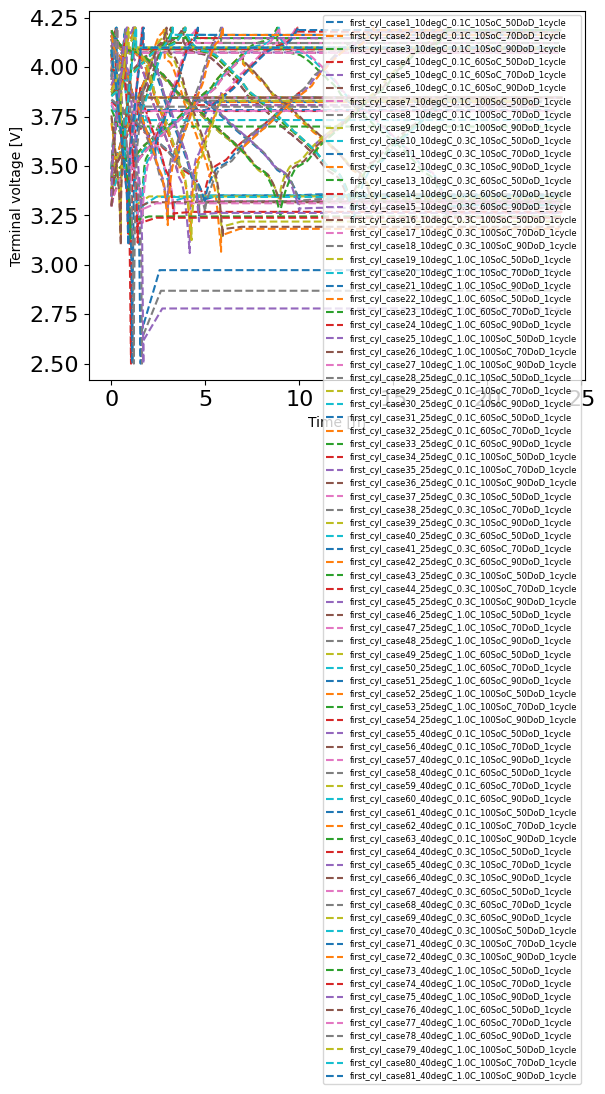

In [6]:
## First cycle for each case
cycles_per_day = 1
days_per_year = 1 #365
years_for_sim = 1
termination_capacity = 70
time_per_cycle = 24/cycles_per_day #in hours
soc_upper_cutoff = 1
soc_lower_cutoff = 0
max_dod = soc_upper_cutoff - soc_lower_cutoff
crate_ref = 0.1
period_charge_discharge = 5
period_rest = 60
safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 50}) #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
simcase_list = []
experiment_list = []
no_steps_list = []
ifcond_cycle_list = []

for n in range(81):
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    dod_case = df["DoD"][n]*0.01
    soc_case = df["SoC"][n]*0.01
    crate = df["C_rate"][n]
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

    t_soc0 = (1-soc_case)*60/crate_ref #time in minutes
    # exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
    # sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    # sol0 = sim0.solve()

    if soc_case == 1:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for 1 seconds")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
        
    else:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
        

    discharge_time = int(60/crate*dod_case) # in minutes
    charge_time = int(60/crate*dod_case) # in minutes
    rest_time = int(time_per_cycle*60) - discharge_time - charge_time

    discharge_string = f"Discharge at {crate}C for {discharge_time} min or until 2.5V ({period_charge_discharge} minute period)"
    charge_string = f"Charge at {crate}C for {charge_time} min or until 4.2V ({period_charge_discharge} minute period)"
    rest_string = f"Rest for {rest_time} min ({period_rest} minute period)"


    if (soc_case-dod_case) >= soc_lower_cutoff:
        list_of_steps_auto = list([discharge_string, charge_string, rest_string])
        #print(f"C1: for Case{simcase}")
        ifcond_cycle = f"C1: for Case{simcase}"
    elif (soc_case+dod_case)<= soc_upper_cutoff:
        list_of_steps_auto = list([charge_string, discharge_string, rest_string])
        #print(f"C2: for Case{simcase}")
        ifcond_cycle = f"C2: for Case{simcase}"
    elif soc_case ==0.5 and dod_case > soc_case:
        discharge_to_soc_time = int(60/crate*(dod_case-soc_case))
        updated_rest_time = rest_time - discharge_to_soc_time
        discharge_to_soc_string = f"Discharge at {crate}C for {discharge_to_soc_time} min ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} min ({period_rest} minute period)"
        #print(f"C3: for Case{simcase}")
        ifcond_cycle = f"C3: for Case{simcase}"
        
        list_of_steps_auto = list([discharge_string, charge_string, discharge_to_soc_string, updated_rest_string]) # discharge_to_soc_string,
    elif soc_case > 0.5 and dod_case > soc_case:
                
        charge_to_soc_time = int(60/crate*(dod_case- (1-soc_case)))
        updated_rest_time = rest_time - charge_to_soc_time
        charge_to_soc_string = f"Charge at {crate}C for {charge_to_soc_time} min ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} minutes ({period_rest} minute period)"
        
        list_of_steps_auto = list([charge_string, discharge_string, charge_to_soc_string, updated_rest_string]) # discharge_to_soc_string,
        #print(f"C4: for Case{simcase}")
        ifcond_cycle = f"C4: for Case{simcase}"
        
        
    else:
        print(f"couldn't get the list of steps for Case{simcase}")
        list_of_steps_auto = list([rest_string])
        ifcond_cycle = f"Condiitons didn't match for Case{simcase}"
        
    steps_total = len(list_of_steps_auto)
        
    simcase_list.append(f"Case {simcase}: {tempC_case}degC, {soc_case*100}%SoC, {crate}C, {dod_case*100}%DoD, {cycles_per_day}cycles")
    no_steps_list.append(steps_total)
    experiment_list.append(list_of_steps_auto)
    ifcond_cycle_list.append(ifcond_cycle)
    
    exp1 = pybamm.Experiment(list_of_steps_auto*cycles_per_day*days_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model1, parameter_values=parameter_values, experiment=exp1, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
        
    t1 = sim1.solution["Time [h]"].entries
    Vc1 = sim1.solution["Terminal voltage [V]"].entries
    Temp1 = sim1.solution["X-averaged cell temperature [K]"].entries

    plt.plot(t1, Vc1, "--", label =f"first_cyl_case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    #plt.plot(t1, Temp1, "--", label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=6)
    df3 = {}
    df3 = pd.DataFrame(df3)
    df3["Time [h]"] =t1
    df3["Terminal voltage [V]"] = Vc1
    df3["X-averaged cell temperature [K]"] = Temp1
    df3.to_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_cyl_case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    
    discharge_time = None
    charge_time = None
    rest_time = None
    discharge_to_soc_time = None
    list_of_steps_auto = None
    updated_rest_time = None
    ifcond_cycle = None
    
    
plt.xlabel("Time [h]")
plt.ylabel("Terminal voltage [V]")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()

# df_conditions["simcase"] = simcase_list
# df_conditions["Experiment"] = experiment_list
# df_conditions["n_steps"] = no_steps_list
# df_conditions["condition"] = ifcond_cycle_list
# df_conditions.to_csv(f"{current_directory}/paperstudies2026/experimentslist_81cases.csv")



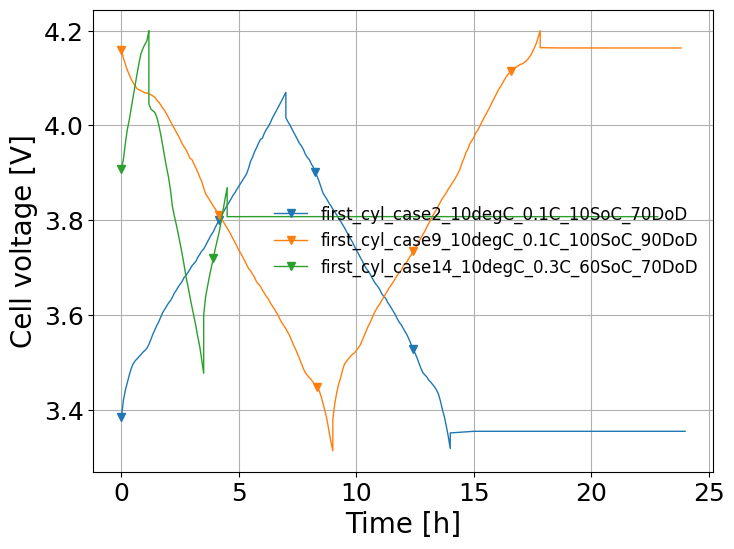

In [18]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(8,6))
b =0
for m in [1,8,13]: #range(15,18):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_cyl_case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='v', markevery=50,linewidth=1, label =f"first_cyl_case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in range(27,54):   #range(27,54):#: #range(5): #(54, 81)
#     n = m
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='*', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in range(54,81): #range(27,54):#: #range(5): #
#     n = m
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='o', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel("Time [h]",fontsize=20)
plt.ylabel("Cell voltage [V]",fontsize=20)
#plt.title('first cycle',fontsize=20)
#plt.ylim([70, 102])
#plt.xlim([-50, 1000])
plt.legend(fontsize=12,loc='center right',framealpha=0.0)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

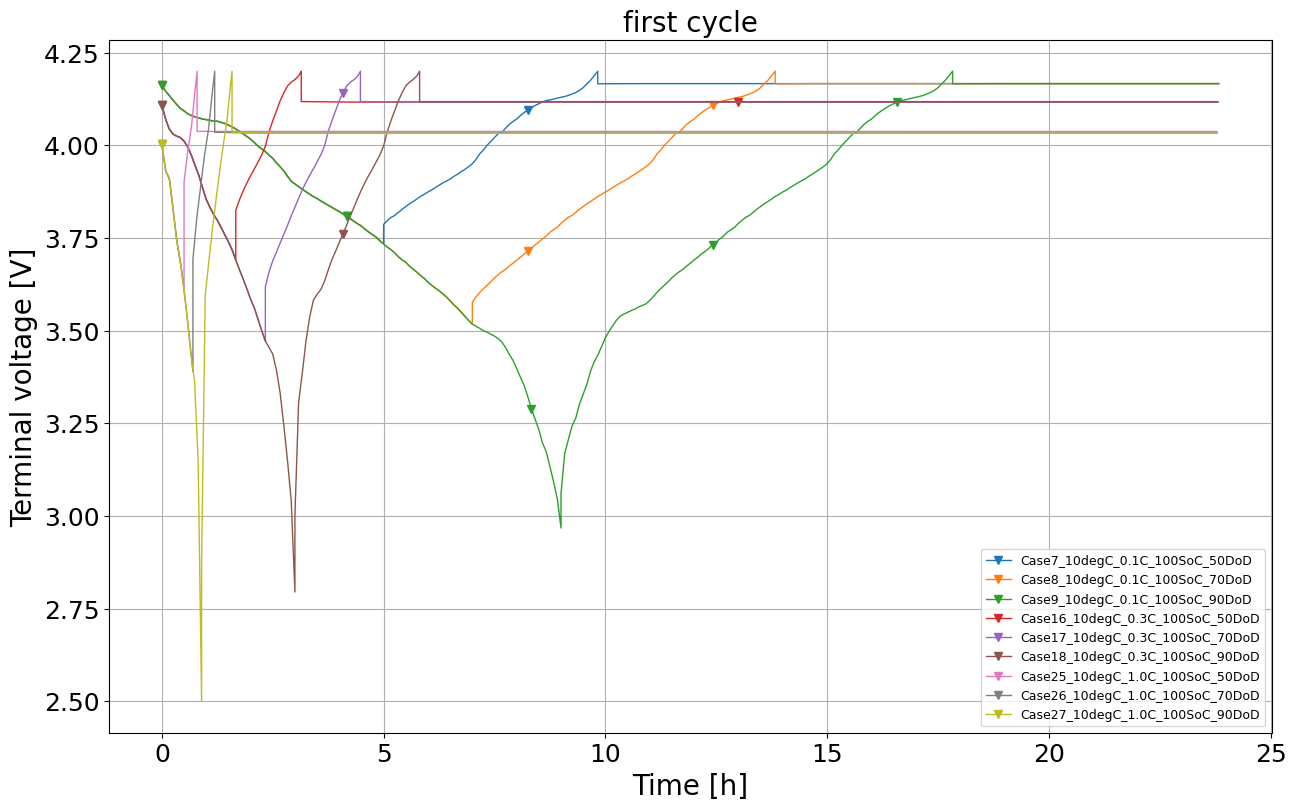

In [ ]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(15,9))
b =0
for m in [6,7,8,15,16,17,24,25,26]: #range(15,18):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='v', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in range(27,54):   #range(27,54):#: #range(5): #(54, 81)
#     n = m
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='*', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in range(54,81): #range(27,54):#: #range(5): #
#     n = m
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='o', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel("Time [h]",fontsize=20)
plt.ylabel("Terminal voltage [V]",fontsize=20)
plt.title('first cycle',fontsize=20)
#plt.ylim([70, 102])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()